# 6-mode HighDimStokesMeasurement example

This notebook simulates a 6-output lantern measured with a 6-superpixel pupil basis. The physical forward path is:

1. apply a superpixel phase mask to a circular tophat pupil,
2. Fourier transform the pupil field to the focal plane,
3. project the focal field onto lantern input modes,
4. apply the lantern coupling matrix,
5. measure output powers.

The Stokes reconstruction recovers each output row only up to a row-wise global phase. That is expected for power-only measurements.

The final section does a backward run: specify desired output powers, choose an output phase convention, solve for superpixel coefficients, and render the pupil phase mask. The ideal complex-superpixel field and the phase-only SLM rendering are shown separately because phase-only masks cannot generally reproduce arbitrary complex coefficients exactly.

In [36]:
import JazLabs.simulator.BeamGenerator as BeamGen
import JazLabs.utils.SuperPixel_lib as SuperPixel
import JazLabs.simulator.BeamProp as BeamProp
import JazLabs.simulator.BasisGenerator as BasisGen

import JazLabs.simulator.PhaseprofsOpticalElements as PhaseProf

import JazLabs.utils.PlotingFunctions.ComplexPlotFunction as cmplxplt

import matplotlib.pyplot as plt
import numpy as np

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

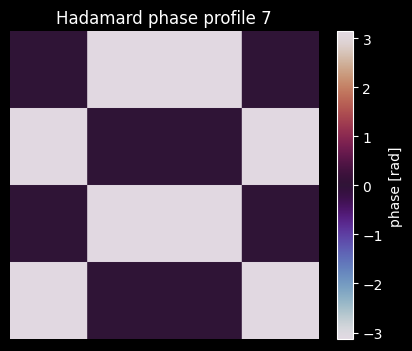

In [37]:
hadamard_fields = BeamGen.make_hadamard_phase_profiles(
    shape=(256, 256),
    n_superpixels_x=4,
    n_superpixels_y=4,
    radius=256,
)
profile_index = 7
phase = np.angle(hadamard_fields[profile_index])
phase = np.ma.masked_where(np.abs(hadamard_fields[profile_index]) == 0, phase)

plt.figure(figsize=(5, 4))
plt.imshow(phase, cmap="twilight", vmin=-np.pi, vmax=np.pi)
plt.colorbar(label="phase [rad]")
plt.title(f"Hadamard phase profile {profile_index}")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

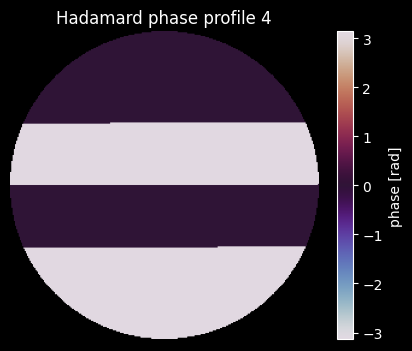

In [38]:
hadamard_fields = BeamGen.make_circular_hadamard_phase_profiles(
    shape=(256, 256),
    n_superpixels_x=4,
    n_superpixels_y=4,
    radius=128,
)
profile_index = 4
phase = np.angle(hadamard_fields[profile_index])
phase = np.ma.masked_where(np.abs(hadamard_fields[profile_index]) == 0, phase)
plt.figure(figsize=(5, 4))
# plt.imshow(phase, cmap="twilight")
plt.imshow(phase, cmap="twilight", vmin=-np.pi, vmax=np.pi)

plt.colorbar(label="phase [rad]")
plt.title(f"Hadamard phase profile {profile_index}")
plt.axis("off")

In [39]:
hadamard_fields.shape

(16, 256, 256)

In [40]:
import numpy as np

def gram_matrix(modes, aperture=None):
    """
    modes: array with shape (N_modes, Ny, Nx), complex fields
    aperture: optional boolean or float mask with shape (Ny, Nx)
    """
    modes = np.asarray(modes, dtype=complex)

    if aperture is not None:
        modes = modes * aperture[None, :, :]

    N = modes.shape[0]
    G = np.zeros((N, N), dtype=complex)

    flat = modes.reshape(N, -1)

    # normalize each mode
    norms = np.sqrt(np.sum(np.abs(flat)**2, axis=1))
    flat = flat / norms[:, None]

    for i in range(N):
        for j in range(N):
            G[i, j] = np.vdot(flat[i], flat[j])  # conjugates first argument

    return G

max off-diagonal: 3.3950620093037287e-13


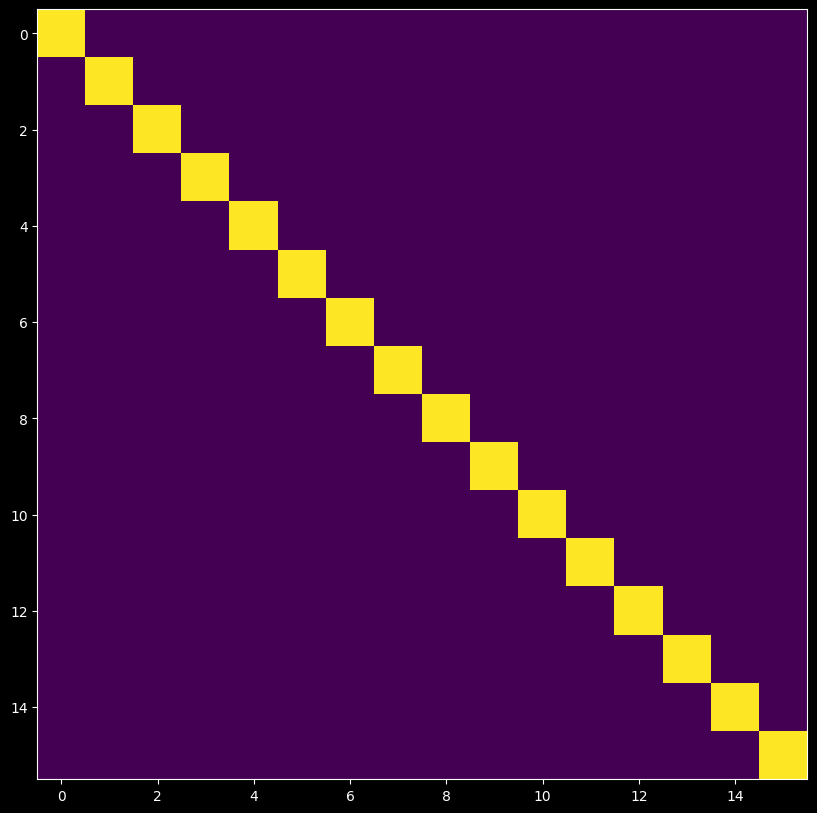

In [41]:
G = gram_matrix(hadamard_fields, )
plt.imshow(np.abs(G), vmin=0, vmax=1)
# print(np.abs(G))
print("max off-diagonal:", np.max(np.abs(G - np.eye(G.shape[0]))))

In [42]:
max off-diagonal: 0.0008615288238703121

SyntaxError: invalid syntax (574055185.py, line 1)

max off-diagonal: 0.007135174292174681


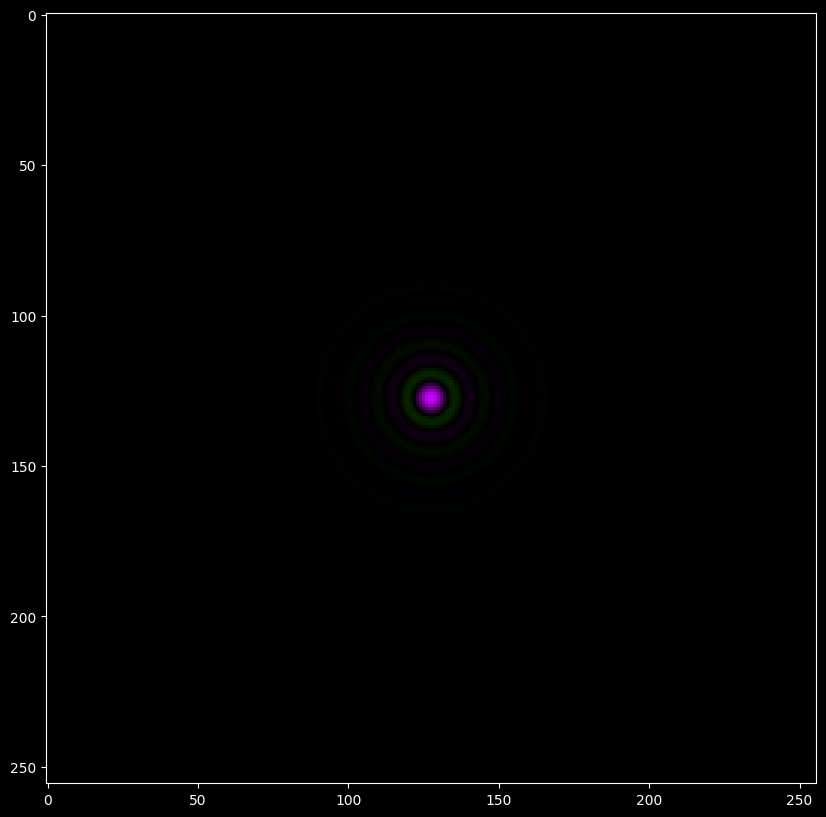

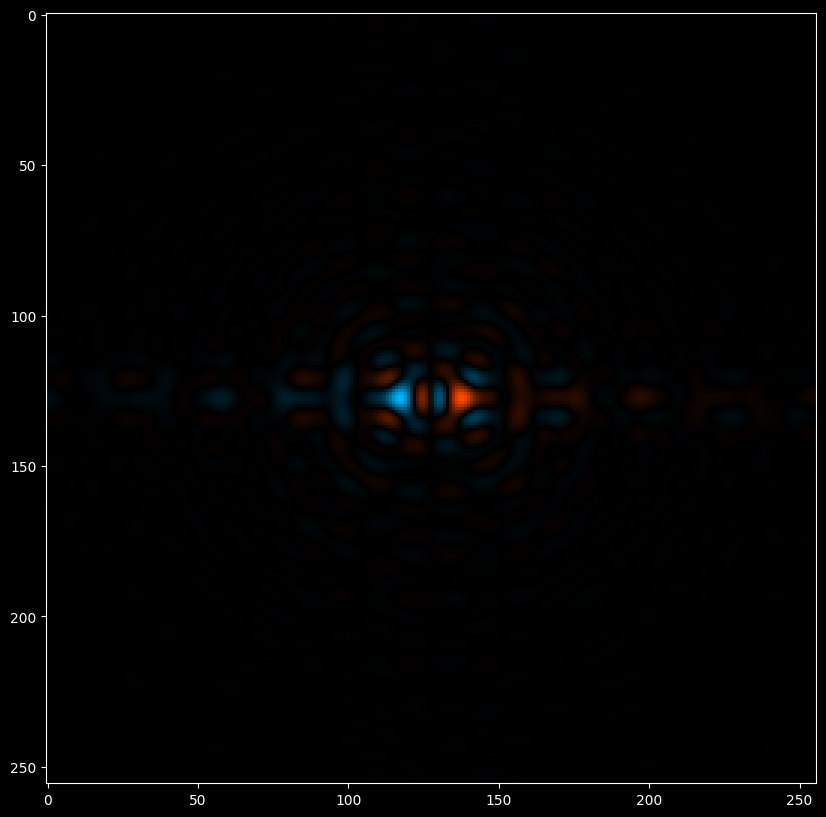

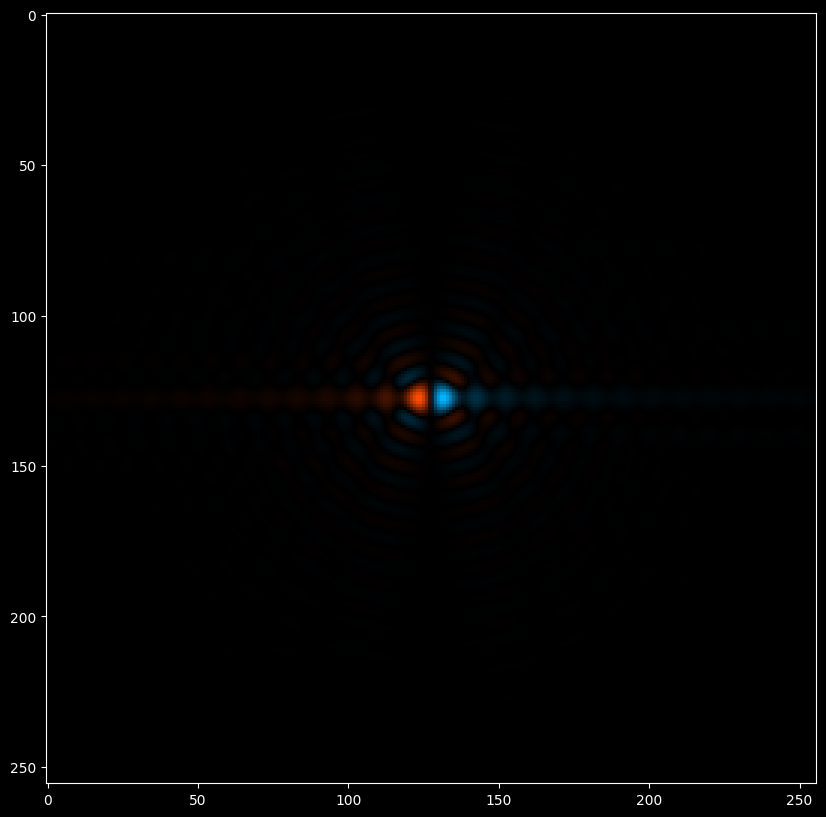

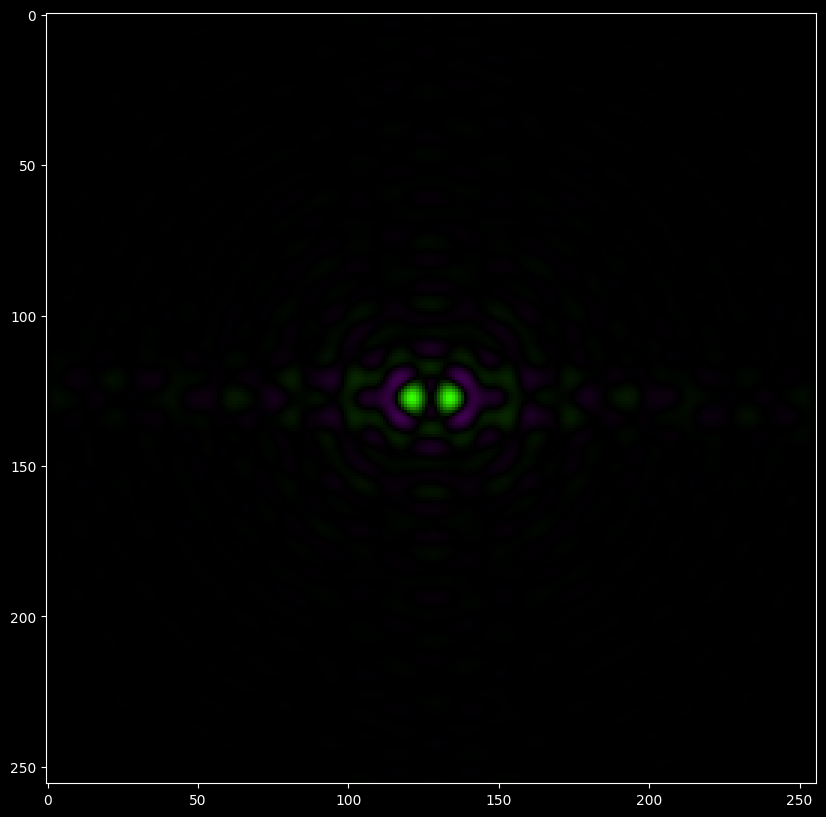

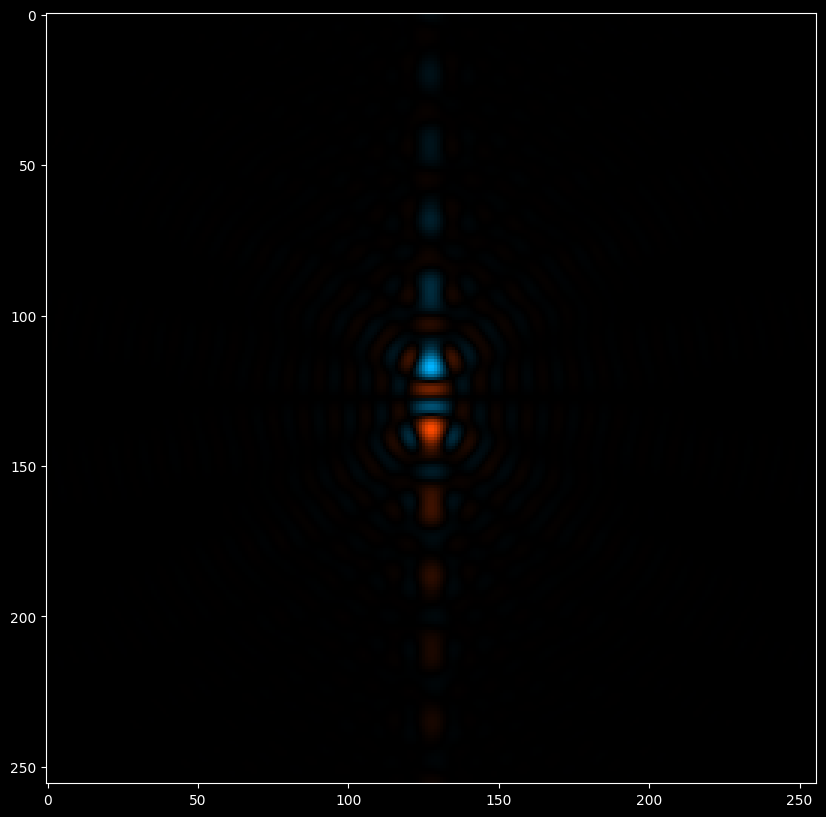

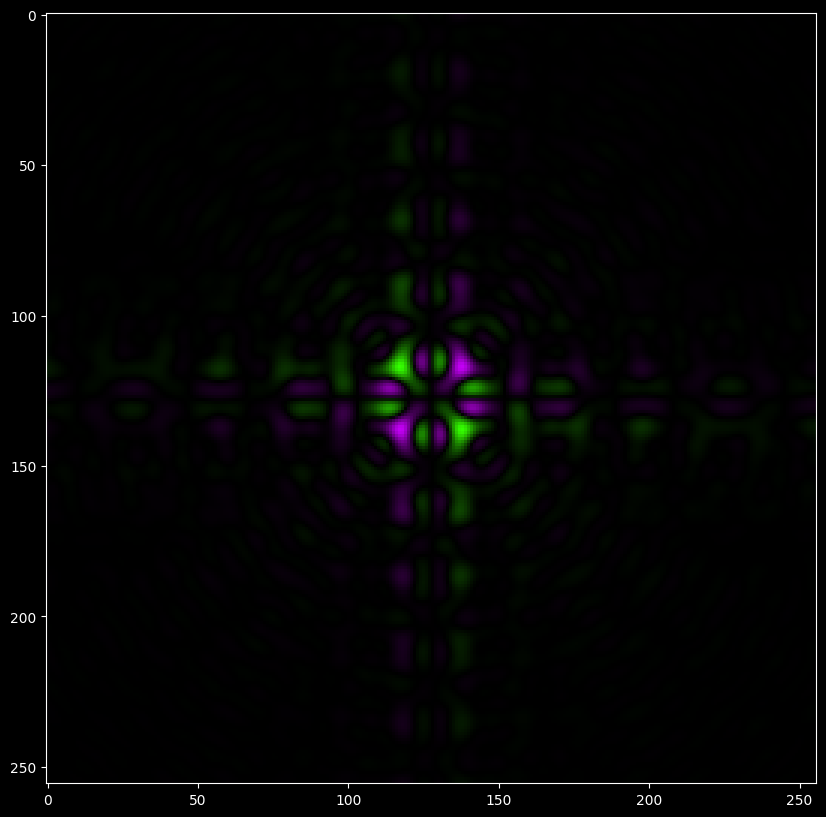

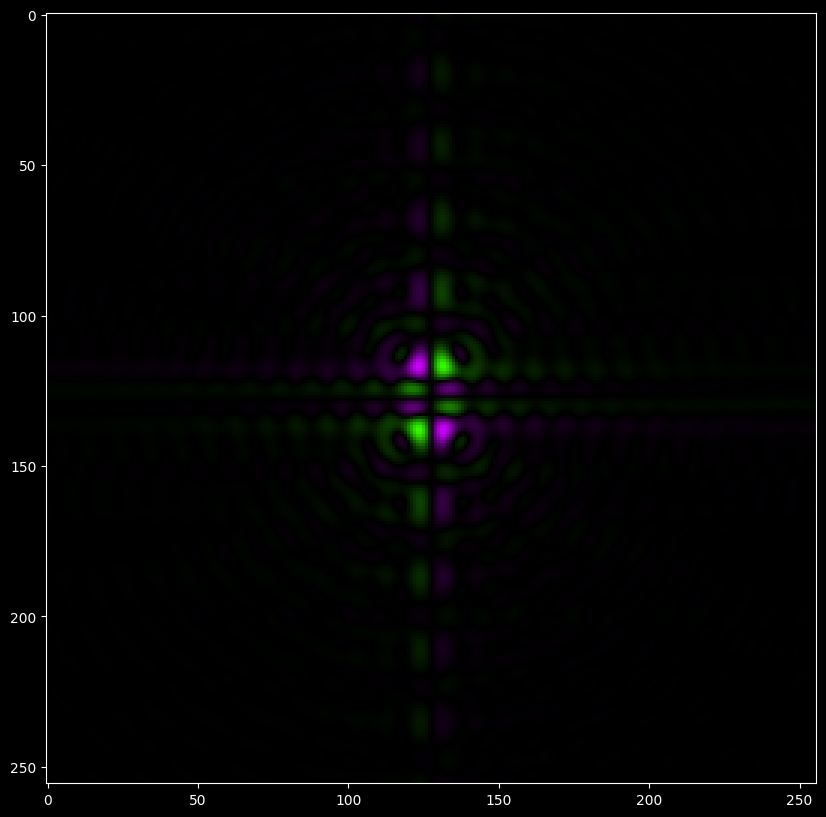

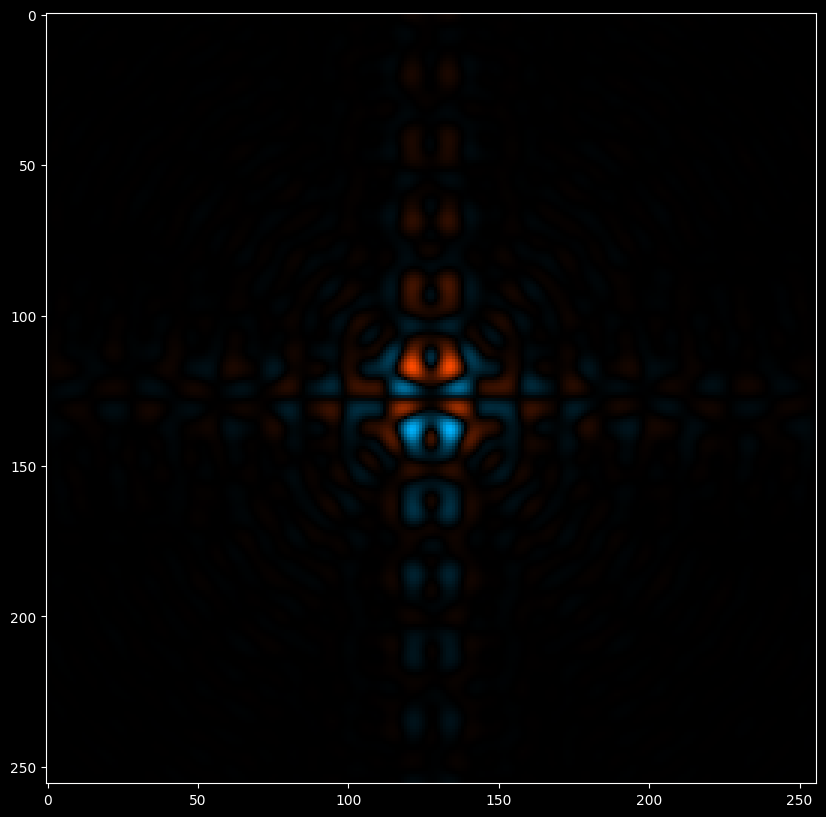

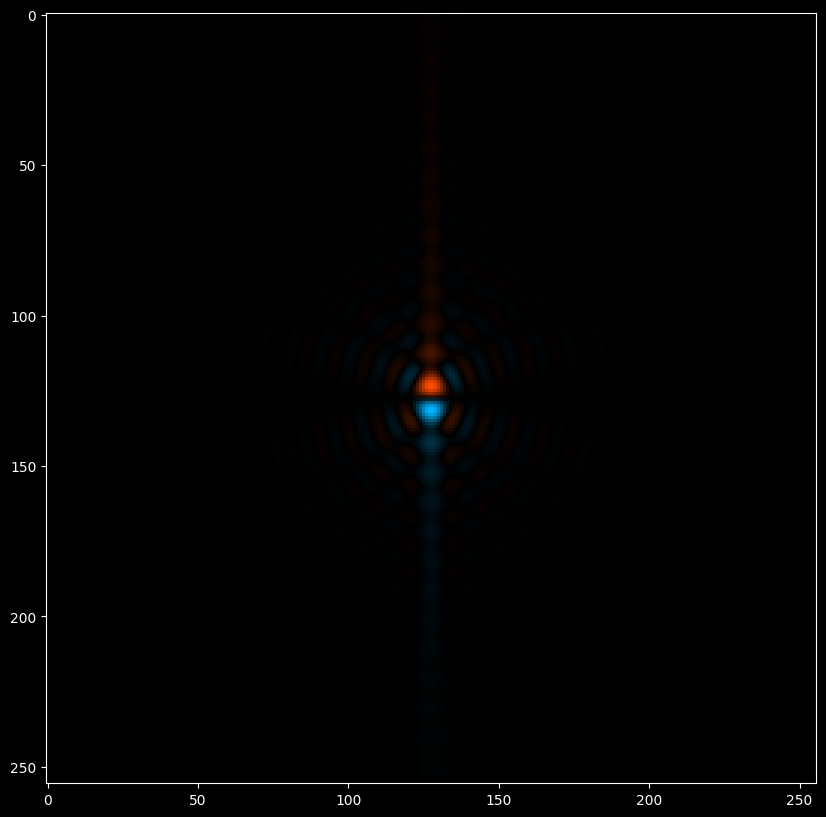

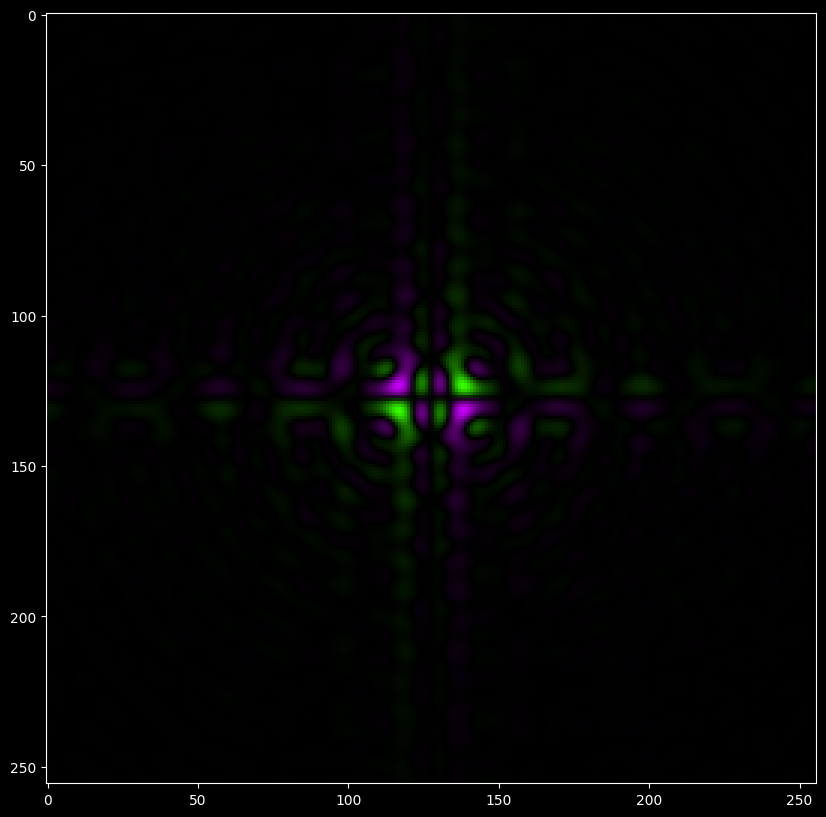

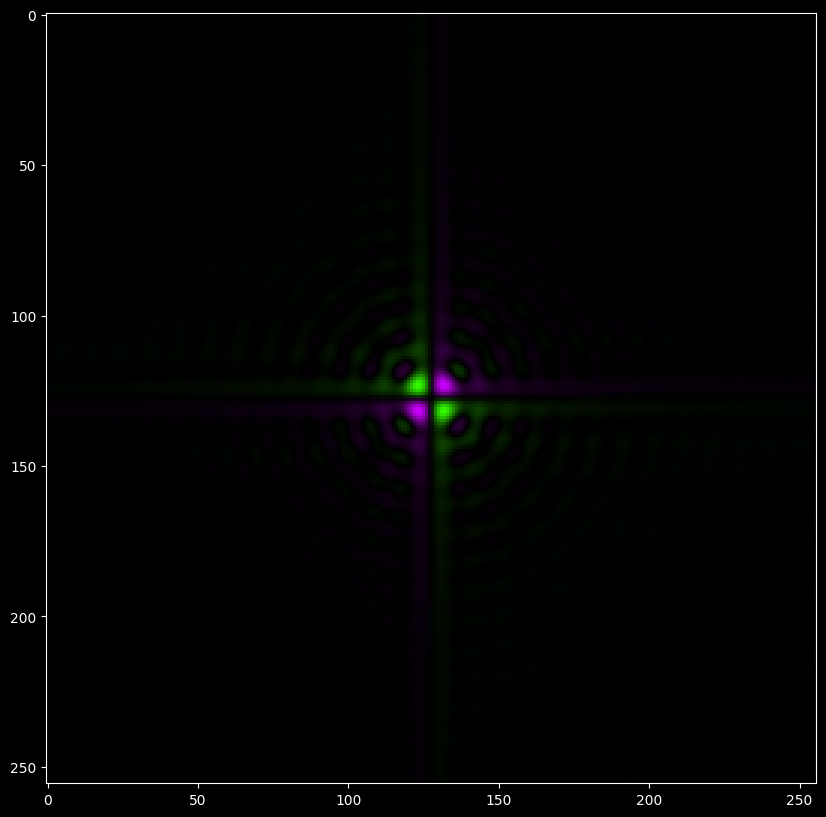

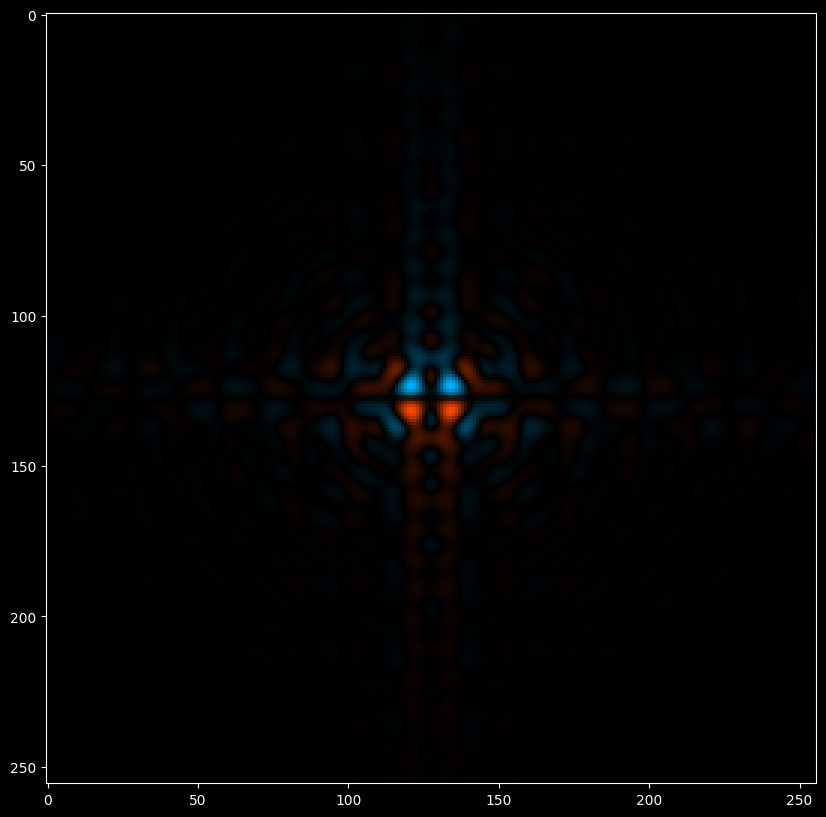

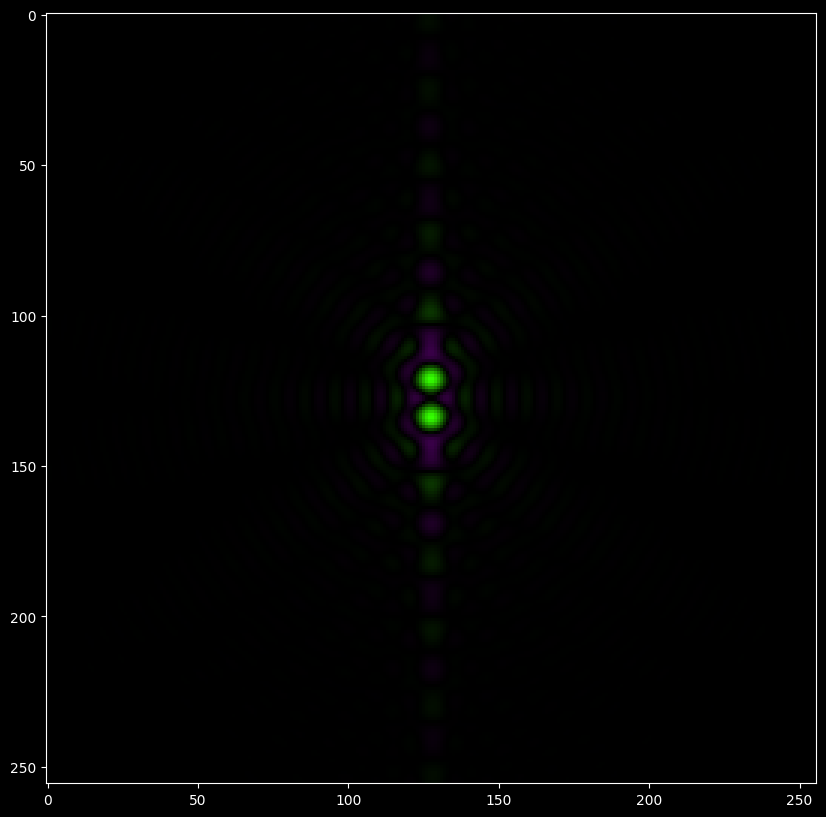

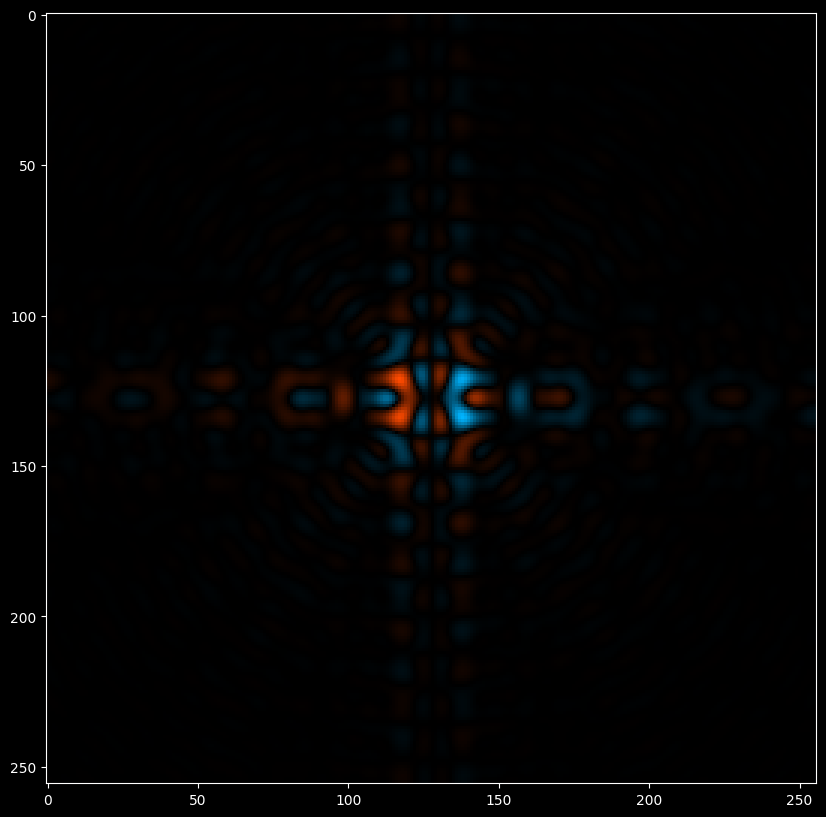

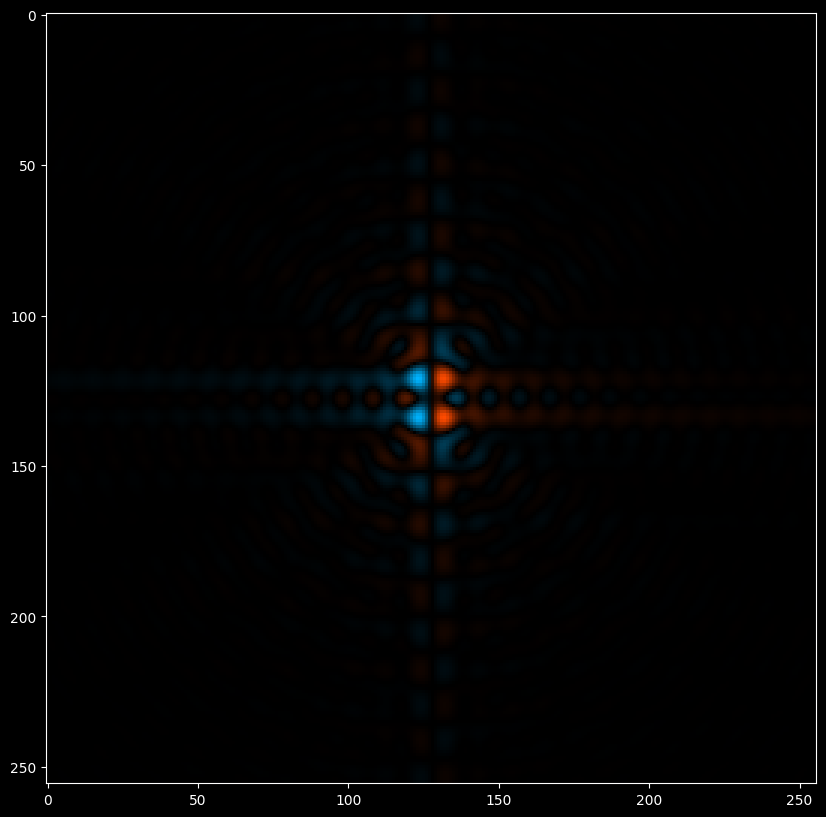

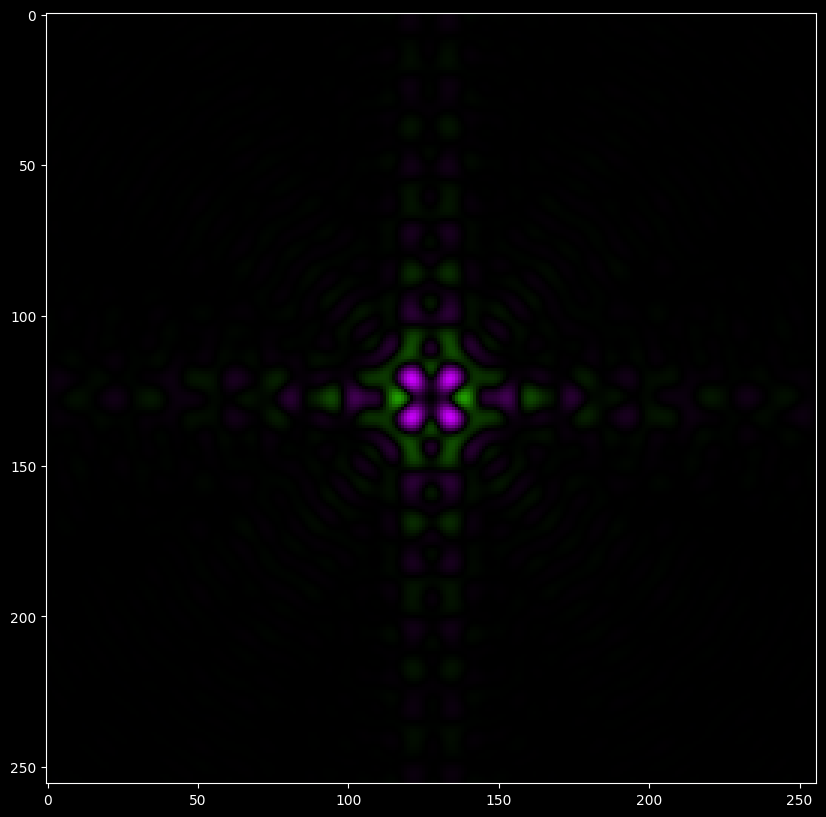

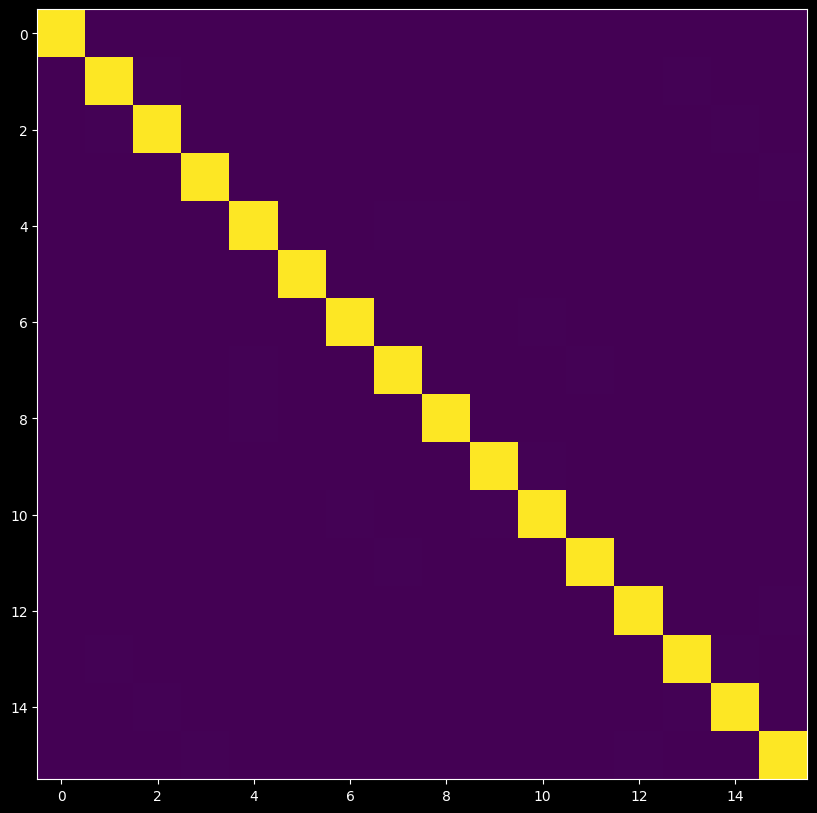

In [43]:
plotFields=True
NxPaddedExt, NyPaddedExt = 2048, 2048
NxFibre, NyFibre = 256, 256
pixel_size = 5e-6


NewShape=(NxPaddedExt, NyPaddedExt)

wavelength = 1550e-9
lenfocal = 20e-3
xmin, xmax = -NxPaddedExt//2 * pixel_size, NxPaddedExt//2 * pixel_size
ymin, ymax = -NyPaddedExt//2 * pixel_size, NyPaddedExt//2 * pixel_size
XGrid = np.linspace(xmin, xmax, NxPaddedExt)
YGrid = np.linspace(ymin, ymax, NyPaddedExt)
XGrid, YGrid = np.meshgrid(XGrid, YGrid)

#make lens phase profile
LensPhase = PhaseProf.LensPhaseProf(focalLen=lenfocal,wavelength=wavelength,XGrid=XGrid,YGrid=YGrid)
Xf, Yf, xf, yf, dxf, dyf=PhaseProf.fourier_plane_coords(NxPaddedExt, NyPaddedExt, dx=pixel_size, dy=pixel_size, wavelength=wavelength, f=lenfocal)
#make transfer matrix for free space propagation
transferMatrix=BeamProp.transferFunctionOfFreeSpace(XGrid,YGrid, dz=lenfocal, wavelength=wavelength)

modeCount=hadamard_fields.shape[0]
FieldAtFibre=np.zeros((modeCount,NxFibre, NyFibre),dtype=complex)
for imode in range(hadamard_fields.shape[0]):
    hadamard_fieldsPadded=BeamProp.pad_array(np.copy(hadamard_fields[imode]), new_shape=NewShape, value=0)
    fieldAtLens = BeamProp.propagateField(hadamard_fieldsPadded, transferMatrix)
    fieldafterlens = fieldAtLens*LensPhase
    fieldAtfibreLargearea = BeamProp.propagateField(fieldafterlens, transferMatrix)
    FieldAtFibre[imode] = BeamProp.crop_array(fieldAtfibreLargearea,crop_shape=(NxFibre, NyFibre))
    if plotFields:
        plt.figure(imode)
        plt.imshow(cmplxplt.ComplexArrayToRgb(FieldAtFibre[imode]))
    
G = gram_matrix(FieldAtFibre, )
plt.figure(modeCount+1)
plt.imshow(np.abs(G), vmin=0, vmax=1)

# plt.figure(2)
# plt.imshow(cmplxplt.ComplexArrayToRgb(FieldAtFibre[2]))

# print(np.abs(G))
print("max off-diagonal:", np.max(np.abs(G - np.eye(G.shape[0]))))

3.0273437499998834e-06 3.0273437499998834e-06


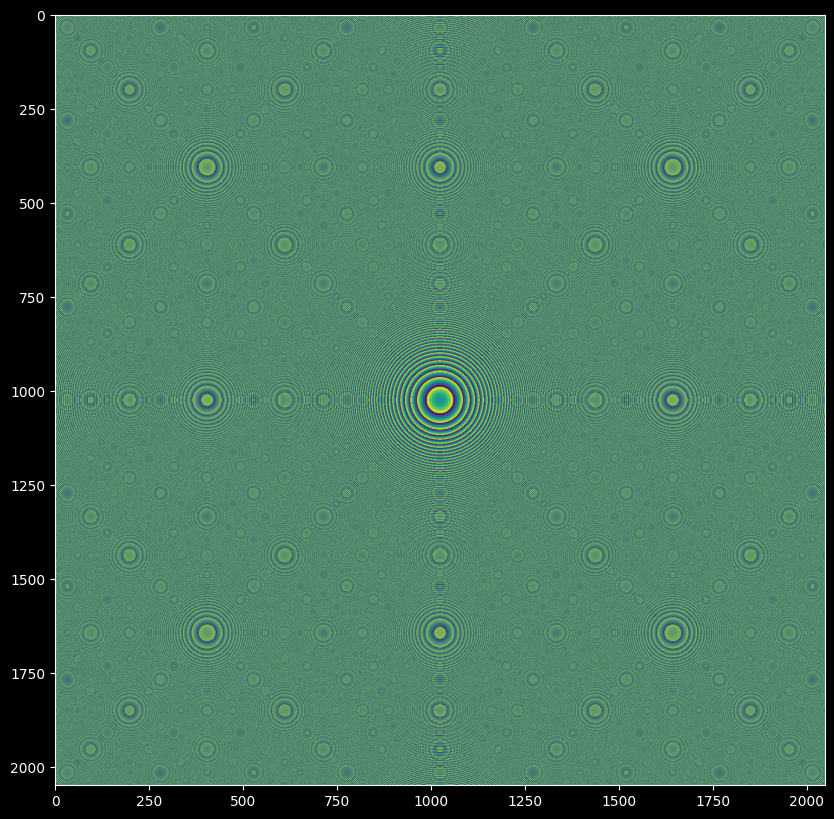

In [44]:
pixel_size = 5e-6
Nx, Ny = 2048, 2048
wavelength = 1550e-9
lenfocal = 20e-3
xmin, xmax = -Nx//2 * pixel_size, Nx//2 * pixel_size
ymin, ymax = -Ny//2 * pixel_size, Ny//2 * pixel_size
XGrid = np.linspace(xmin, xmax, Nx)
YGrid = np.linspace(ymin, ymax, Ny)
XGrid, YGrid = np.meshgrid(XGrid, YGrid)
LensPhase = PhaseProf.LensPhaseProf(focalLen=lenfocal,wavelength=wavelength,XGrid=XGrid,YGrid=YGrid)
Xf, Yf, xf, yf, dxf, dyf=PhaseProf.fourier_plane_coords(Nx, Ny, dx=pixel_size, dy=pixel_size, wavelength=wavelength, f=lenfocal)
print(dxf, dyf)
plt.imshow(np.angle(LensPhase))

In [45]:
import numpy as np


def make_random_T(num_outputs, num_modes, seed=1):
    rng = np.random.default_rng(seed)
    T = rng.normal(size=(num_outputs, num_modes)) + 1j * rng.normal(size=(num_outputs, num_modes))

    # Normalise rows so powers are sensible
    T /= np.linalg.norm(T, axis=1, keepdims=True)
    return T


def make_stokes_input_states(num_modes):
    """
    Creates known input states:
    1. single modes
    2. pairwise superpositions with phases 0, pi/2, pi, 3pi/2
    """
    states = []
    labels = []

    # Single-mode measurements
    for i in range(num_modes):
        a = np.zeros(num_modes, dtype=complex)
        a[i] = 1.0
        states.append(a)
        labels.append(("single", i))

    phases = [0, np.pi / 2, np.pi, 3 * np.pi / 2]

    # Pairwise interference measurements
    for i in range(num_modes):
        for j in range(i + 1, num_modes):
            for phi in phases:
                a = np.zeros(num_modes, dtype=complex)
                a[i] = 1 / np.sqrt(2)
                a[j] = np.exp(1j * phi) / np.sqrt(2)
                states.append(a)
                labels.append(("pair", i, j, phi))

    return np.array(states), labels


def simulate_powers(T, input_states):
    """
    T shape: (num_outputs, num_modes)
    input_states shape: (num_measurements, num_modes)

    returns powers shape: (num_outputs, num_measurements)
    """
    amplitudes = T @ input_states.T
    powers = np.abs(amplitudes) ** 2
    return powers


def reconstruct_T_from_powers(powers, input_states):
    """
    Reconstructs T up to an arbitrary phase per output row.

    powers shape: (num_outputs, num_measurements)
    input_states shape: (num_measurements, num_modes)
    """
    num_outputs, num_measurements = powers.shape
    num_modes = input_states.shape[1]

    # Build linear system:
    # P_m = a_m^H Q a_m
    # where Q = t^H t
    A = np.zeros((num_measurements, num_modes * num_modes), dtype=complex)

    for m, a in enumerate(input_states):
        A[m, :] = np.outer(np.conj(a), a).reshape(-1)

    T_rec = np.zeros((num_outputs, num_modes), dtype=complex)

    for k in range(num_outputs):
        p = powers[k]

        # Solve for Q_k
        q_vec, *_ = np.linalg.lstsq(A, p, rcond=None)
        Q = q_vec.reshape(num_modes, num_modes)

        # Clean numerical noise
        Q = 0.5 * (Q + Q.conj().T)

        # Since Q = t^H t, it should be rank 1.
        eigvals, eigvecs = np.linalg.eigh(Q)
        idx = np.argmax(eigvals)

        t = np.sqrt(np.maximum(eigvals[idx], 0)) * eigvecs[:, idx].conj()

        T_rec[k] = t

    return T_rec


def align_row_phases(T_rec, T_true):
    """
    Power-only reconstruction cannot recover absolute phase of each output row.
    This aligns rows only for checking the simulation.
    """
    T_aligned = T_rec.copy()

    for k in range(T_true.shape[0]):
        phase = np.vdot(T_aligned[k], T_true[k])
        phase /= np.abs(phase)
        T_aligned[k] *= phase

    return T_aligned

def ConvertModeViaTransformMatrix(transformMatrix,InputModes,ApplyMatrixToLeftOrRight="Left"):
    if(ApplyMatrixToLeftOrRight=="Left"):
        ApplyMatrixToLeft=True
    elif(ApplyMatrixToLeftOrRight=="Right"):
        ApplyMatrixToLeft=False
    else:
         ApplyMatrixToLeft=True
         print("You have not input a argument for ApplyMatrixToLeftOrRight so it has default to Left. You need to either put Left or Right") 
    Dims=np.shape(InputModes)
    modeCountInput=Dims[0]
    Ny=Dims[1]
    Nx=Dims[2]
    Dims=np.shape(transformMatrix)
    modeCountTransform=Dims[0]
    
    if(ApplyMatrixToLeft):
        transMode=np.zeros([modeCountTransform,Ny,Nx],dtype=complex)
    else:
        transMode=np.zeros([modeCountInput,Ny,Nx],dtype=complex)
        
    transModetemp=np.zeros([modeCountInput,Ny,Nx],dtype=complex);
    for i in range(modeCountTransform):
        for j in range(modeCountInput):
            if(ApplyMatrixToLeft):
                transModetemp[j,:,:]=transformMatrix[i,j]*InputModes[j,:,:];
            else:
                # transModetemp[j,:,:]=transModetemp[j,:,:]+transformMatrix[i,j]*InputModes[i,:,:];
                transModetemp[j,:,:]=transformMatrix[j,i]*InputModes[i,:,:];
                
            # The line below was the original line and you may need to go fix stuff up for the gate mode generation
            # transModetemp[j,:,:]=transformMatrix[j,i]*InputModes[j,:,:];
        # if(ApplyMatrixToLeft):
        #     transMode[i,:,:]=np.sum(transModetemp,0)
        # else:
        #     transMode=transModetemp
        transMode[i,:,:]=np.sum(transModetemp,0)
    return transMode

In [55]:
num_outputs = 6
num_modes = 16   # change this to 16, 64, etc.

T_true = make_random_T(num_outputs, num_modes)

input_states, labels = make_stokes_input_states(num_modes)
powers = simulate_powers(T_true, input_states)



T_rec = reconstruct_T_from_powers(powers, input_states)

T_rec_aligned = align_row_phases(T_rec, T_true)

print("T_true shape:", T_true.shape)
print("powers shape:", powers.shape)
print("T_rec shape:", T_rec.shape)

print("reconstruction error:")
print(np.linalg.norm(T_true - T_rec_aligned) / np.linalg.norm(T_true))

T_true shape: (6, 16)
powers shape: (6, 496)
T_rec shape: (6, 16)
reconstruction error:
7.361144487616825e-16


In [47]:
powers.shape

(6, 66)

In [48]:
input_states.T.shape

(6, 66)

In [56]:
num_outputs = 6
num_modes = 16   # change this to 16, 64, etc.

T_true = make_random_T(num_outputs, num_modes)

input_states, labels = make_stokes_input_states(num_modes)
modeCount = hadamard_fields.shape[0]
FeildAtFibre = np.zeros(hadamard_fields.shape, dtype=complex)
for imode in range(modeCount):
    fieldAtLens = BeamProp.propagateField(hadamard_fields[imode], transferMatrix)
    fieldafterlens = fieldAtLens*LensPhase
    fieldAtfibreOverSizedSpace = BeamProp.propagateField(fieldafterlens, transferMatrix)
    FeildAtFibre[imode,:,:]=BeamProp.crop_array(fieldAtfibreOverSizedSpace,crop_shape=(256,256))
    

FeildOutofFibre=ConvertModeViaTransformMatrix(T_true,FeildAtFibre,ApplyMatrixToLeftOrRight="Left")
#powers = simulate_powers(T_true, input_states)



T_rec = reconstruct_T_from_powers(powers, input_states)

T_rec_aligned = align_row_phases(T_rec, T_true)

print("T_true shape:", T_true.shape)
print("powers shape:", powers.shape)
print("T_rec shape:", T_rec.shape)

print("reconstruction error:")
print(np.linalg.norm(T_true - T_rec_aligned) / np.linalg.norm(T_true))

ValueError: operands could not be broadcast together with shapes (256,256) (2048,2048) 

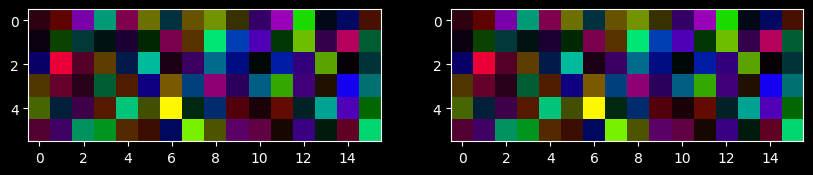

In [57]:
plt.subplot(1, 2, 1)
plt.imshow(cmplxplt.ComplexArrayToRgb(T_true))
plt.subplot(1, 2, 2)
plt.imshow(cmplxplt.ComplexArrayToRgb(T_rec_aligned))

In [53]:
input_states.shape

(66, 6)

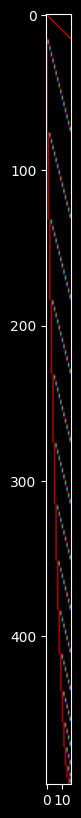

In [58]:
plt.imshow(cmplxplt.ComplexArrayToRgb(input_states))

## Backwards solve: lantern powers to Hadamard superposition

This section uses the reconstructed transmission matrix to find one set of Hadamard-mode coefficients whose predicted lantern output powers match a measured six-port power vector. Powers do not contain output phase, so the solution is not unique; `phase_trials` samples possible output phases and keeps a low-norm coefficient vector.


In [59]:
from JazLabs.simulator.HighDimStokesMeasurement import (
    reconstruct_field_from_mode_coeffs,
    solve_input_coeffs_from_output_powers,
)

# This matrix must map Hadamard coefficients to lantern output amplitudes.
# If your reconstruction returns the raw lantern matrix, replace this with
# the effective matrix that includes propagation/projection from Hadamard modes.
T_hadamard = T_rec

n_outputs, n_hadamard_modes = T_hadamard.shape
if n_hadamard_modes != hadamard_fields.shape[0]:
    raise ValueError(
        f"T_hadamard has {n_hadamard_modes} input modes, but "
        f"hadamard_fields has {hadamard_fields.shape[0]} modes. "
        "Use the effective Hadamard-to-lantern matrix here."
    )

# Replace this with your experimental measured power vector, shape (6,).
# The demo fallback makes a synthetic measurement from a random superposition.
if "measured_powers" not in globals():
    rng = np.random.default_rng(4)
    demo_coeffs = rng.normal(size=n_hadamard_modes) + 1j * rng.normal(size=n_hadamard_modes)
    demo_coeffs = demo_coeffs / np.linalg.norm(demo_coeffs)
    measured_powers = np.abs(T_hadamard @ demo_coeffs) ** 2

measured_powers = np.asarray(measured_powers, dtype=float)
if measured_powers.shape != (n_outputs,):
    raise ValueError(f"measured_powers must have shape ({n_outputs},)")

solution = solve_input_coeffs_from_output_powers(
    T_hadamard,
    measured_powers,
    phase_trials=2000,
    seed=1,
)

hadamard_coeffs = solution.commanded_coeffs
reconstructed_field = reconstruct_field_from_mode_coeffs(hadamard_coeffs, hadamard_fields)
phase_mask = np.angle(reconstructed_field)

print("Hadamard coeffs shape:", hadamard_coeffs.shape)
print("Power residual norm:", solution.residual)
print("Measured powers:", measured_powers)
print("Predicted powers:", solution.predicted_powers)


ImportError: cannot import name 'make_circular_tophat' from 'JazLabs.simulator.HighDimStokesMeasurement.tomography' (/Users/s4356803/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/Documents/JazLabs/src/JazLabs/simulator/HighDimStokesMeasurement/tomography.py)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(np.arange(n_hadamard_modes), np.abs(hadamard_coeffs))
axes[0].set_title("Hadamard coefficient amplitudes")
axes[0].set_xlabel("Hadamard mode")
axes[0].set_ylabel("|coefficient|")

axes[1].plot(measured_powers, "o", label="measured")
axes[1].plot(solution.predicted_powers, "x", label="predicted")
axes[1].set_title("Lantern powers")
axes[1].set_xlabel("output port")
axes[1].set_ylabel("power")
axes[1].legend()

phase_for_plot = np.ma.masked_where(np.abs(reconstructed_field) == 0, phase_mask)
im = axes[2].imshow(phase_for_plot, cmap="twilight", vmin=-np.pi, vmax=np.pi)
axes[2].set_title("Superimposed Hadamard phase")
axes[2].axis("off")
fig.colorbar(im, ax=axes[2], label="phase [rad]")
plt.tight_layout()
